In [1]:
import sys
import polars as pl
from hmmlearn import hmm
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import pandas as pd

In [2]:
from pathlib import Path

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config as src_config, data_utils, plots, strategy_utils

TRAIN_PATH = src_config.TRAIN_PATH
TEST_PATH = src_config.TEST_PATH

# HMM + Bayesian Network Accumulation Strategy

Use a Hidden Markov Model to infer latent market regimes, then apply a Bayesian Network to convert observed evidence (valuation, volatility, price state) into a probability of an accumulation opportunity.

**Data Preparation**
Load BRK on-chain metrics, compute log returns, GARCH conditional volatility, and rolling MVRV features used as HMM inputs.

**HMM Training**
Fit a 3-state Gaussian HMM on [return, GARCH volatility, MVRV z-score, price vs active price]. Assign qualitative regime labels (accumulation / neutral / euphoric) by inspecting per-regime statistics.

**Bayesian Classification**
Discretize continuous features (valuation state, volatility state, active price state) and fit a Discrete Bayesian Network using Maximum Likelihood Estimation. Query the network to compute `P(accumulation_opportunity = "yes")` for each day.

**Accumulation Signal & Backtest**
Convert the Bayesian probability into a daily allocation weight, smooth with a 7-day rolling mean, and backtest `HMMBayesAccumulationStrategy` year-by-year (2018–2023) against MVRV and uniform DCA baselines.

In [3]:
# HMM → latent market regime
# Bayesian Network → probability of accumulation opportunity
# Stacksats strategy → daily DCA multiplier

In [4]:
features = [
    "active_price",

    "realized_price",

    "mvrv",

    "mvrv_zscore",

    "market_cap",

    "supply_btc"
]

In [5]:
import polars as pl
df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("day_utc") >= pl.date(2018, 1, 1))
    .filter(pl.col("metric").is_in(features))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

In [6]:
df = df.to_pandas()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(how="all")

df.isna().mean().sort_values(ascending=False)

date              0.0
active_price      0.0
market_cap        0.0
mvrv              0.0
realized_price    0.0
supply_btc        0.0
price_usd         0.0
dtype: float64

In [7]:
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date").sort_index()

In [8]:
ts = df.copy()
ts["mvrv_deviation"] = ts["mvrv"] - ts["mvrv"].rolling(365).mean()
ts["mvrv_z_rolling"] = (
    (ts["mvrv"] - ts["mvrv"].rolling(365).mean())
    / ts["mvrv"].rolling(365).std()
)

In [9]:
from arch import arch_model

from hmmlearn.hmm import GaussianHMM

from sklearn.preprocessing import StandardScaler

In [10]:
model_df = ts.copy()

model_df["btc_log_return"] = np.log(
    model_df["price_usd"] / model_df["price_usd"].shift(1)
)

model_df["btc_return_pct"] = model_df["btc_log_return"] * 100

model_df = model_df.replace([np.inf, -np.inf], np.nan)

In [11]:
returns = model_df["btc_return_pct"].dropna()

garch = arch_model(
    returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_result = garch.fit(disp="off")

print(garch_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:               btc_return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5576.05
Distribution:      Standardized Student's t   AIC:                           11162.1
Method:                  Maximum Likelihood   BIC:                           11190.6
                                              No. Observations:                 2190
Date:                      Wed, Jun 17 2026   Df Residuals:                     2189
Time:                              15:58:17   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

In [12]:
model_df.loc[returns.index, "garch_volatility"] = garch_result.conditional_volatility

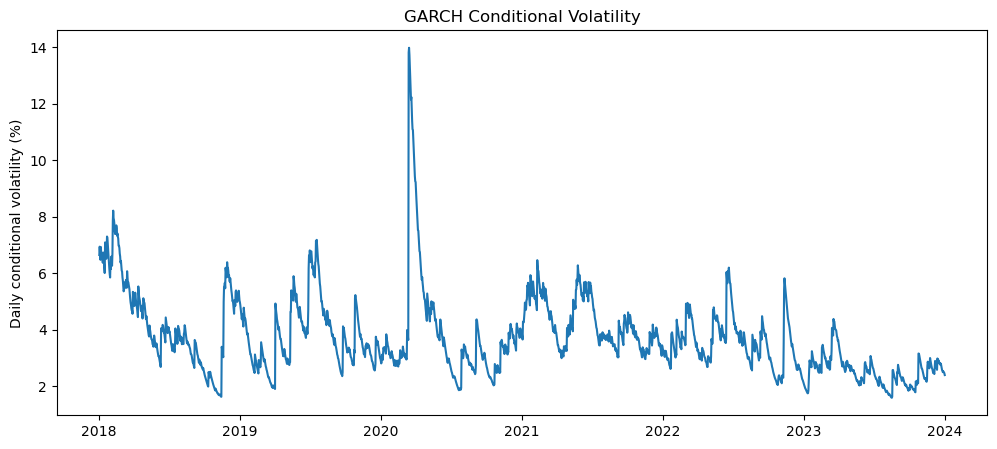

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(model_df["garch_volatility"])
plt.title("GARCH Conditional Volatility")
plt.ylabel("Daily conditional volatility (%)")
plt.show()

In [14]:
hmm_features = pd.DataFrame(index=model_df.index)

hmm_features["return"] = model_df["btc_log_return"]
hmm_features["volatility"] = model_df["garch_volatility"]
hmm_features["mvrv_z"] = model_df["mvrv_z_rolling"]
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

hmm_features = hmm_features.replace([np.inf, -np.inf], np.nan).dropna()

In [15]:
scaler = StandardScaler()

X = scaler.fit_transform(hmm_features)

In [16]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm.fit(X)

regime_probs = hmm.predict_proba(X)

In [17]:
hmm_features["regime"] = hmm.predict(X)

In [18]:
hmm_features["price_vs_active"] = (
    model_df["price_usd"] / model_df["active_price"] - 1
)

In [19]:
for i in range(hmm.n_components):
    hmm_features[f"regime_prob_{i}"] = regime_probs[:, i]

In [20]:
prob_cols = [f"regime_prob_{i}" for i in range(hmm.n_components)]

plot_df = model_df.join(
    hmm_features[["regime","price_vs_active"] + prob_cols],
    how="left"
)

plot_df = plot_df.rename(columns={"regime": "hmm_regime"})

In [21]:
regime_summary = (
    hmm_features
    .groupby("regime")
    .mean()
)

regime_summary

,return,volatility,mvrv_z,price_vs_active,regime_prob_0,regime_prob_1,regime_prob_2
regime,,,,,,,
0,0.006480,5.216008,1.379440,2.420407,0.979914,0.002754,0.017332
1,-0.001964,3.954175,-0.617299,2.312177,0.000783,0.997434,0.001783
2,0.001105,2.880455,0.251039,1.248468,0.005578,0.000239,0.994183


In [22]:
plot_df.columns.tolist()

['active_price',
 'market_cap',
 'mvrv',
 'realized_price',
 'supply_btc',
 'price_usd',
 'mvrv_deviation',
 'mvrv_z_rolling',
 'btc_log_return',
 'btc_return_pct',
 'garch_volatility',
 'hmm_regime',
 'price_vs_active',
 'regime_prob_0',
 'regime_prob_1',
 'regime_prob_2']

In [23]:
# MVRV tells us valuation.
# GARCH volatility tells us stress.
# Price vs active price tells us participant profitability.
# HMM regime tells us latent market state.

In [24]:
bn_df = plot_df.copy()

bn_df["valuation_state"] = pd.cut(
    bn_df["mvrv_z_rolling"],
    bins=[-np.inf, -1.0, 1.0, np.inf],
    labels=["cheap", "neutral", "expensive"]
)

bn_df["volatility_state"] = pd.cut(
    bn_df["garch_volatility"].rank(pct=True),
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["low", "medium", "high"]
)

bn_df["active_price_state"] = pd.cut(
    bn_df["price_vs_active"],
    bins=[-np.inf, -0.05, 0.10, np.inf],
    labels=["below_active", "near_active", "above_active"]
)

bn_df["regime_state"] = bn_df["hmm_regime"].astype(str)

In [25]:
# Accumulation target
# Cheap valuation + stress = accumulation opportunity
bn_df["accumulation_opportunity"] = np.where(
    (
        (bn_df["valuation_state"] == "cheap")
        & (
            (bn_df["volatility_state"] == "high")
            | (bn_df["active_price_state"] == "below_active")
        )
    ),
    "yes",
    "no"
)

In [26]:
bn_train = bn_df[
    [
        "regime_state",
        "valuation_state",
        "volatility_state",
        "active_price_state",
        "accumulation_opportunity",
    ]
].dropna()

bn_train = bn_train.astype(str)

In [27]:
from pgmpy.models import BayesianNetwork, DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/arafat/miniforge3/envs/capstone/lib/python3.11/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [28]:
# Accumulation opportunity depends on:
# - latent HMM regime
# - valuation
# - volatility
# - active price state
model = DiscreteBayesianNetwork([
    ("regime_state", "accumulation_opportunity"),
    ("valuation_state", "accumulation_opportunity"),
    ("volatility_state", "accumulation_opportunity"),
    ("active_price_state", "accumulation_opportunity"),
])

In [29]:
model.fit(bn_train)

model.check_model()

infer = VariableElimination(model)

In [30]:
def get_accumulation_probability(row):
    evidence = {
        "regime_state": str(row["regime_state"]),
        "valuation_state": str(row["valuation_state"]),
        "volatility_state": str(row["volatility_state"]),
        "active_price_state": str(row["active_price_state"]),
    }

    try:
        result = infer.query(
            variables=["accumulation_opportunity"],
            evidence=evidence,
            show_progress=False,
        )

        states = result.state_names["accumulation_opportunity"]
        values = result.values

        prob_yes = dict(zip(states, values)).get("yes", 0.0)

        return float(prob_yes)

    except Exception:
        return 0.0

In [31]:
bn_df["bayes_accumulation_prob"] = bn_df.apply(
    get_accumulation_probability,
    axis=1
)

In [32]:
# P(accumulation) = 0.0 → 1.0x DCA
# P(accumulation) = 0.5 → 1.75x DCA
# P(accumulation) = 1.0 → 2.5x DCA

In [33]:
bn_df["hmm_bayes_allocation_weight"] = (
    1.0 + 1.5 * bn_df["bayes_accumulation_prob"]
).clip(0.50, 2.50)

In [34]:
bn_df["hmm_bayes_allocation_weight"] = (
    bn_df["hmm_bayes_allocation_weight"]
    .rolling(7)
    .mean()
    .fillna(bn_df["hmm_bayes_allocation_weight"])
)

In [35]:
bn_df["hmm_bayes_allocation_weight"] = (
    bn_df["hmm_bayes_allocation_weight"]
    .shift(1)
    .fillna(1.0)
)

In [36]:
signals_pd = (
    bn_df
    .reset_index()
    [["date", "hmm_bayes_allocation_weight", "bayes_accumulation_prob"]]
)

btc_df_bayes = (
    df.reset_index()
    .merge(signals_pd, on="date", how="left")
)

btc_df_bayes["hmm_bayes_allocation_weight"] = (
    btc_df_bayes["hmm_bayes_allocation_weight"]
    .fillna(1.0)
) 

In [37]:
btc_df_bayes_pl = pl.from_pandas(btc_df_bayes).with_columns(
    pl.col("date").cast(pl.Date)
)

In [38]:
from stacksats import BaseStrategy

class HMMBayesAccumulationStrategy(BaseStrategy):
    strategy_id = "hmm-bayes-accumulation"
    version = "1.0.0"

    def __init__(self, signal_df, min_weight=0.50, max_weight=2.50):
        self.min_weight = min_weight
        self.max_weight = max_weight

        self.signal_df = (
            signal_df
            .select(["date", "hmm_bayes_allocation_weight"])
            .with_columns(pl.col("date").cast(pl.Date))
        )

    def params(self):
        return {
            "min_weight": self.min_weight,
            "max_weight": self.max_weight,
            "signal_column": "hmm_bayes_allocation_weight",
        }

    def propose_weight(self, state):
        current_date = (
            state.features
            .select("date")
            .tail(1)
            .item()
        )

        signal_row = self.signal_df.filter(
            pl.col("date") == current_date
        )

        if signal_row.is_empty():
            signal = 1.0
        else:
            signal = (
                signal_row
                .select("hmm_bayes_allocation_weight")
                .item()
            )

        if signal is None:
            signal = 1.0

        signal = float(signal)
        signal = max(self.min_weight, min(signal, self.max_weight))

        return state.uniform_weight * signal

In [39]:
start_date = str(btc_df_bayes_pl.select(pl.col("date").min()).item())
end_date = str(btc_df_bayes_pl.select(pl.col("date").max()).item())

In [40]:
from stacksats import StrategyRunner, BacktestConfig, ExportConfig

hmm_bayes = HMMBayesAccumulationStrategy(signal_df=btc_df_bayes_pl)

runner = StrategyRunner()

hmm_bayes_bt = runner.backtest(
    hmm_bayes,
    config=BacktestConfig(
        start_date=start_date,
        end_date=end_date,
    ),
    btc_df=btc_df_bayes_pl,
)

In [41]:
hmm_bayes_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2018-01-01 → 2018-12-31""",5842.827929,31422.726801,14736.064632,14736.064632,34.766505,34.766505,2.2027e-13
"""2018-01-02 → 2019-01-01""",5842.827929,31422.726801,14787.64918,14787.64918,34.968165,34.968165,1.9895e-13
"""2018-01-03 → 2019-01-02""",5842.827929,31422.726801,14839.550357,14839.89885,35.171063,35.172426,0.001362
"""2018-01-04 → 2019-01-03""",5842.827929,31422.726801,14893.784195,14892.797686,35.383081,35.379224,-0.003857
"""2018-01-05 → 2019-01-04""",5842.827929,31422.726801,14947.312798,14947.084879,35.592341,35.59145,-0.000891
…,…,…,…,…,…,…,…
"""2022-12-28 → 2023-12-27""",2263.929335,6055.677106,3645.624389,3645.624389,36.43953,36.43953,-3.5527e-14
"""2022-12-29 → 2023-12-28""",2263.929335,6055.677106,3635.497492,3635.497492,36.172452,36.172452,-1.4211e-14
"""2022-12-30 → 2023-12-29""",2263.929335,6055.677106,3625.550662,3625.550662,35.910124,35.910124,-3.5527e-14


In [42]:
hmm_bayes_bt.summary()

'Score: 53.97% | Win Rate: 70.55% | Exp-Decay Percentile: 37.38% | Uniform Exp-Decay: 37.29% | Exp-Decay Multiple: 1.002x | Windows: 1827'

In [43]:
from stacksats import UniformStrategy, ComparisonConfig

uniform_strategy = UniformStrategy()

result = runner.compare(
    strategies=[
        hmm_bayes,
        uniform_strategy
    ],
    config=ComparisonConfig(
        start_date=start_date,
        end_date=end_date,
        baseline="uniform",
        strict=False,
        output_dir="output",
    ),
    btc_df=btc_df_bayes_pl,
)

result

ComparisonResult(baseline_selector='uniform', comparison_window={'start_date': '2018-01-01', 'end_date': '2023-12-31', 'strict': False, 'min_win_rate': 50.0}, rows=[ComparisonRow(selector='hmm-bayes-accumulation', strategy_id='hmm-bayes-accumulation', strategy_version='1.0.0', intent_mode='propose', tier=None, promotion_stage=None, validation_passed=True, judgment_label='validation-passed', win_rate=70.5528188286809, score=53.96883025193296, exp_decay_percentile=37.38484167518501, multiple_vs_uniform=1.002499398542104, score_delta_vs_baseline=35.323012743437545, exp_decay_delta_vs_baseline=0.09320665819417684, is_baseline=False), ComparisonRow(selector='uniform', strategy_id='uniform', strategy_version='1.0.0', intent_mode='propose', tier='stable', promotion_stage='promoted', validation_passed=False, judgment_label='validation-failed', win_rate=0.0, score=18.645817508495416, exp_decay_percentile=37.29163501699083, multiple_vs_uniform=0.999999999999999, score_delta_vs_baseline=0.0, exp_

The HMM estimates hidden market regimes.
The Bayesian network takes the regime plus observed evidence and estimates the probability that today is an accumulation opportunity.
The strategy converts that probability into a DCA multiplier.

In [44]:
strategies_train = {
    "dynamic": hmm_bayes,
    "baseline": UniformStrategy(),
}

train_years  = range(src_config.TRAIN_START_YEAR, src_config.SPLIT_YEAR)   # 2018–2023
merged_train = strategy_utils.run_year_by_year(strategies_train, btc_df_bayes_pl, train_years, runner)

perf_vf   = strategy_utils.compute_performance_summary(merged_train, "dynamic", "baseline")

print(f"[Train] HMM Bayes SPD : {perf_vf['sats_per_dollar_dynamic']:.2f}")
print(f"[Train] Baseline SPD    : {perf_vf['sats_per_dollar_baseline']:.2f}")
print(f"HMM Bayes {abs(perf_vf['pct_diff_vs_baseline']):.2f}% {perf_vf['performance_label']} than Uniform")

2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
[Train] HMM Bayes SPD : 8755.20
[Train] Baseline SPD    : 8418.79
HMM Bayes 4.00% better than Uniform


## Adding Test data

In [45]:
df_test = (
    pl.scan_parquet(TEST_PATH)
    .filter(pl.col("day_utc") >= pl.date(2024, 1, 1)) #Test data should anyways start from Jan 1, 2024
    .filter(pl.col("metric").is_in(features))
    .select(["day_utc", "metric", "value"])
    .collect()
    .pivot(
        on="metric",
        index="day_utc",
        values="value",
        aggregate_function="first",
    )
    .with_columns(
        (pl.col("market_cap") / pl.col("supply_btc")).alias("price_usd")
    )
    .rename({"day_utc": "date"})
    .filter(
        pl.col("price_usd").is_finite()
        & (pl.col("price_usd") > 0)
    )
    .sort("date")
)

In [46]:
test_df = df_test.to_pandas()
combined = pd.concat([

    df.tail(365),

    test_df

])

combined["mvrv_z_rolling"] = (

    combined["mvrv"]

    - combined["mvrv"].rolling(365).mean()

) / combined["mvrv"].rolling(365).std()

In [47]:
test_df["mvrv_z_rolling"] = combined.loc[

    test_df.index,

    "mvrv_z_rolling"

]


def make_base_features(df):
    out = df.copy()

    out["btc_log_return"] = np.log(
        out["price_usd"] / out["price_usd"].shift(1)
    )

    out["btc_return_pct"] = out["btc_log_return"] * 100

    out["price_vs_active"] = (
        out["price_usd"] / out["active_price"] - 1
    )

    out["price_200d_ma"] = (
        out["price_usd"]
        .rolling(200)
        .mean()
    )

    out["trend_state"] = np.where(
        out["price_usd"] > out["price_200d_ma"],
        "uptrend",
        "downtrend"
    )

    return out


test_raw = test_df.copy()
test_raw["date"] = pd.to_datetime(test_raw["date"])
test_raw = test_raw.sort_values("date").set_index("date")


test_model_df = make_base_features(test_raw)

In [48]:
test_model_df["garch_volatility"] = (
    test_model_df["btc_return_pct"]
    .rolling(30)
    .std()
)


hmm_feature_cols = [
    "btc_log_return",
    "garch_volatility",
    "mvrv_z_rolling",
    "price_vs_active",
]

test_hmm_features = pd.DataFrame(index=test_model_df.index)
test_hmm_features["return"] = test_model_df["btc_log_return"]
test_hmm_features["volatility"] = test_model_df["garch_volatility"]
test_hmm_features["mvrv_z"] = test_model_df["mvrv_z_rolling"]
test_hmm_features["price_vs_active"] = (
    test_model_df["price_usd"] / test_model_df["active_price"] - 1
)

test_hmm_features = test_hmm_features.replace(

    [np.inf, -np.inf], np.nan

).dropna()

X_test = scaler.transform(test_hmm_features)

test_regimes = hmm.predict(X_test)
test_regime_probs = hmm.predict_proba(X_test)

In [49]:
test_hmm_features["hmm_regime"] = test_regimes

for i in range(hmm.n_components):
    test_hmm_features[f"regime_prob_{i}"] = test_regime_probs[:, i]


test_plot_df = test_model_df.join(
    test_hmm_features[
        ["hmm_regime"] + [f"regime_prob_{i}" for i in range(hmm.n_components)]
    ],
    how="left"
)

test_bn_df = test_plot_df.copy()

test_bn_df["valuation_state"] = pd.cut(
    test_bn_df["mvrv_z_rolling"],
    bins=[-np.inf, -1.0, 1.0, np.inf],
    labels=["cheap", "neutral", "expensive"]
)

test_bn_df["volatility_state"] = pd.cut(
    test_bn_df["garch_volatility"].rank(pct=True),
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["low", "medium", "high"]
)

test_bn_df["active_price_state"] = pd.cut(
    test_bn_df["price_vs_active"],
    bins=[-np.inf, -0.05, 0.10, np.inf],
    labels=["below_active", "near_active", "above_active"]
)

test_bn_df["regime_state"] = test_bn_df["hmm_regime"].astype(str)

In [50]:
test_bn_df["bayes_accumulation_prob"] = test_bn_df.apply(
    get_accumulation_probability,
    axis=1
)

test_bn_df["hmm_bayes_allocation_weight"] = (
    1.0 + 1.5 * test_bn_df["bayes_accumulation_prob"]
).clip(0.50, 2.50)

test_bn_df["hmm_bayes_allocation_weight"] = (
    test_bn_df["hmm_bayes_allocation_weight"]
    .rolling(7)
    .mean()
    .fillna(test_bn_df["hmm_bayes_allocation_weight"])
)

test_bn_df["hmm_bayes_allocation_weight"] = (
    test_bn_df["hmm_bayes_allocation_weight"]
    .shift(1)
    .fillna(1.0)
)

signals_test = (
    test_bn_df
    .reset_index()
    [["date", "hmm_bayes_allocation_weight"]]
)

btc_test_bayes = (
    test_raw.reset_index()
    .merge(signals_test, on="date", how="left")
)

btc_test_bayes["hmm_bayes_allocation_weight"] = (
    btc_test_bayes["hmm_bayes_allocation_weight"].fillna(1.0)
)

btc_test_bayes_pl = pl.from_pandas(btc_test_bayes).with_columns(
    pl.col("date").cast(pl.Date)
)


test_start = str(btc_test_bayes_pl.select(pl.col("date").min()).item())
test_end = str(btc_test_bayes_pl.select(pl.col("date").max()).item())

print(f"Test period: {test_start} to {test_end}")

Test period: 2024-01-01 to 2026-03-13


In [51]:
hmm_bayes_test = HMMBayesAccumulationStrategy(
    signal_df=btc_test_bayes_pl
)

strategies_test = {
    "dynamic": hmm_bayes_test,
    "baseline": UniformStrategy(),
}

test_years  = range(src_config.SPLIT_YEAR, src_config.TEST_END_YEAR + 1)   # 2024–2025
merged_test = strategy_utils.run_year_by_year(strategies_test, df_test, test_years, runner)

# perf_test_vf   = strategy_utils.compute_performance_summary(merged_test, "dynamic", "baseline")
# perf_test_mvrv = strategy_utils.compute_performance_summary(merged_test, "mvrv",    "baseline")

2024: exported 365 rows
2024: exported 365 rows
2025: exported 365 rows
2025: exported 365 rows


In [52]:
strategy_utils.compute_performance_summary(merged_test, "dynamic", "baseline")

{'total_dynamic_btc': 0.02593170516704897,
 'total_baseline_btc': 0.025842443973114457,
 'sats_per_dollar_dynamic': 1296.5852583524486,
 'sats_per_dollar_baseline': 1292.122198655723,
 'pct_diff_vs_baseline': 0.345405388234095,
 'performance_label': 'better'}

In [53]:
combined_plot_df = (
    pd.concat([
        merged_train.to_pandas(), 
        merged_test.to_pandas()
        ])
    .sort_values("date")
    .reset_index(drop=True)
)
combined_plot_df["date"] = pd.to_datetime(combined_plot_df["date"])


cols = plots.StrategyColumns(
    weight="dynamic_weight",
    spd="sats_per_dollar_dynamic",
    sats_accum="sats_accum_dynamic",
)

# Full period
full_plot = plots.plot_strategy_full_period(
    combined_plot_df, 
    cols, 
    "HMM BAYES Strategy", 
    date_range=("2018-01-01", str(combined_plot_df["date"].max().date())),
    test_start_date="2024-01-01"
)
plt.show()

In [54]:
test_end = str('2025-12-31')
test_end

'2025-12-31'

In [55]:
hmm2_test_bt = runner.backtest(
    hmm_bayes_test,
    config=BacktestConfig(
        start_date=test_start,
        end_date=test_end,
    ),
    btc_df=btc_test_bayes_pl,
)
hmm2_test_bt.to_dataframe()

window,min_sats_per_dollar,max_sats_per_dollar,uniform_sats_per_dollar,dynamic_sats_per_dollar,uniform_percentile,dynamic_percentile,excess_percentile
str,f64,f64,f64,f64,f64,f64,f64
"""2024-01-01 → 2024-12-30""",942.777195,2528.060843,1589.861093,1589.861093,40.818178,40.818178,-3.5527e-14
"""2024-01-02 → 2024-12-31""",942.777195,2528.060843,1586.574307,1586.574307,40.610847,40.610847,-7.1054e-15
"""2024-01-03 → 2025-01-01""",942.777195,2528.060843,1583.375013,1583.375013,40.409035,40.409035,-7.1054e-15
"""2024-01-04 → 2025-01-02""",942.777195,2528.060843,1579.810682,1579.810682,40.184196,40.184196,-2.8422e-14
"""2024-01-05 → 2025-01-03""",942.777195,2528.060843,1576.393441,1576.393441,39.968636,39.968636,-4.2633e-14
…,…,…,…,…,…,…,…
"""2024-12-28 → 2025-12-27""",801.416263,1311.019777,996.869049,1006.905267,38.353893,40.32331,1.969417
"""2024-12-29 → 2025-12-28""",801.416263,1311.019777,997.111228,1006.753351,38.401416,40.293499,1.892083
"""2024-12-30 → 2025-12-29""",801.416263,1311.019777,997.331164,1006.708582,38.444574,40.284714,1.84014


In [56]:
hmm2_test_bt.summary()

'Score: 58.14% | Win Rate: 75.75% | Exp-Decay Percentile: 40.53% | Uniform Exp-Decay: 38.02% | Exp-Decay Multiple: 1.066x | Windows: 367'

In [57]:
hmm2_comparison = runner.compare(

    strategies=[

        uniform_strategy,

        hmm_bayes_test,

    ],

    config=ComparisonConfig(

        start_date=test_start,

        end_date=test_end,

    ),

    btc_df=btc_test_bayes_pl,

)

In [58]:
hmm2_comparison.to_dataframe()

selector,strategy_id,strategy_version,intent_mode,tier,promotion_stage,validation_passed,judgment_label,win_rate,score,exp_decay_percentile,multiple_vs_uniform,score_delta_vs_baseline,exp_decay_delta_vs_baseline,is_baseline
str,str,str,str,str,str,bool,str,f64,f64,f64,f64,f64,f64,bool
"""uniform""","""uniform""","""1.0.0""","""propose""","""stable""","""promoted""",false,"""validation-failed""",0.0,19.011162,38.022323,1.0,0.0,0.0,true
"""hmm-bayes-accumulation""","""hmm-bayes-accumulation""","""1.0.0""","""propose""",null,null,true,"""validation-passed""",75.749319,58.139533,40.529748,1.065946,39.128372,2.507425,false
